# **02 - Bias Analysis**

The objective of this analysis is to evaluate the integrity and fairness of the credit application dataset following the initial cleaning phase. In the context of a Data Ecosystem and Governance framework, this step ensures that the data used to train the automated credit scoring system is accurate, representative, and compliant with ethical standards, such as those outlined in the EU AI Act.

In [23]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
file_name = 'raw_credit_applications.json' 

if os.path.exists(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    df_raw = pd.json_normalize(data)
    print("Good! File uploaded.")
    display(df_raw.head())
else:
    print(f"ERROR: File '{file_name}' not found.")

Good! File uploaded.


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


In [10]:
# Listar ficheiros para garantir que o nome está correto
print("Files:", os.listdir())

file_name = 'cleaned_credit_applications.json' 

if os.path.exists(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    df_clean = pd.json_normalize(data)
    print("Good! File uploaded.")
    display(df_clean.head())
else:
    print(f"ERROR: File '{file_name}' not found.")

df=df_clean

Files: ['.git', '.gitignore', '.ipynb_checkpoints', '02-bias-analysis.ipynb', 'cleaned_credit_applications.json', 'cleaned_credit_data.csv', 'data', 'Data_Quality_Final.ipynb', 'notebooks', 'presentation', 'raw_credit_applications.json', 'README.md', 'reports', 'src']
Good! File uploaded.


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,notes,ssn_conflict_flag,dob_parsed,age_calculated
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,male,2001-09-03,10036,...,31212.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,9.840960e+11,23.8
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,male,NaN,10032,...,17915.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,male,NaN,10075,...,37909.0,True,NaN,vacation,3.7,59000.0,None,False,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,male,NaN,10077,...,0.0,True,NaN,not_specified,4.3,34000.0,None,False,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,male,NaN,10080,...,31763.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,NaN,NaN


# Data Cleaning Audit

In the context of the DEGO project, the Data Cleaning Audit serves as the essential bridge between raw data ingestion and responsible model development using the cleaned data. Within a Data Governance framework, this audit ensures that the dataset is correctly "clean" and legally compliant with the standards set by the EU AI Act.

Following the initial data sanitization and technical cleaning performed by the Data Engineer, the Data Scientist assumes the role of Data Quality Auditor. This transition ensures that the dataset is not only structurally sound but also verified for statistical integrity and alignment with the project's governance standards.

For better results the Data Scientist is independent from the Data Engineer, the method is to compare df_raw with df_cleaned without looking at the changes made in the Data Engineer document.

### Null Analysis

In [11]:
# Calculate Nulls for Raw Data
raw_nulls = df_raw.isnull().sum()
raw_pct = (raw_nulls / len(df_raw)) * 100

# Calculate Nulls for Cleaned Data
clean_nulls = df_clean.isnull().sum()
clean_pct = (clean_nulls / len(df_clean)) * 100

# Combine into a single Comparison Table
comparison_table = pd.DataFrame({
    'Raw: Nulls': raw_nulls,
    'Raw: %': raw_pct.round(2),
    'Clean: Nulls': clean_nulls,
    'Clean: %': clean_pct.round(2)
})

# Final display
print("DATA CLEANING VERIFICATION: MISSING VALUES COMPARISON")
print(comparison_table)
print()

# Impact Analysis

# Calculation for Raw Data
raw_nulls = df_raw.isnull().sum()
raw_pct = (raw_nulls / len(df_raw)) * 100

# Calculation for Cleaned Data
clean_nulls = df_clean.isnull().sum()
clean_pct = (clean_nulls / len(df_clean)) * 100

# Create the Insight Table
quality_insight = pd.DataFrame({
    'Raw %': raw_pct.round(2),
    'Clean %': clean_pct.round(2),
    'Improvement (pp)': (raw_pct - clean_pct).round(2) # pp = percentage points
})

# Sort by where the most cleaning happened
quality_insight = quality_insight.sort_values(by='Improvement (pp)', ascending=False)

print("DATA CLEANING IMPACT ANALYSIS")
print(quality_insight)

DATA CLEANING VERIFICATION: MISSING VALUES COMPARISON
                                  Raw: Nulls  Raw: %  Clean: Nulls  Clean: %
_id                                      0.0    0.00           0.0       0.0
age_calculated                           NaN     NaN         357.0      71.4
applicant_info.date_of_birth             1.0    0.20         357.0      71.4
applicant_info.email                     0.0    0.00          11.0       2.2
applicant_info.full_name                 0.0    0.00           0.0       0.0
applicant_info.gender                    1.0    0.20           2.0       0.4
applicant_info.ip_address                5.0    1.00           4.0       0.8
applicant_info.ssn                       5.0    1.00           4.0       0.8
applicant_info.zip_code                  1.0    0.20           0.0       0.0
decision.approved_amount               210.0   41.83         208.0      41.6
decision.interest_rate                 210.0   41.83         208.0      41.6
decision.loan_approved

### Gender Distribution

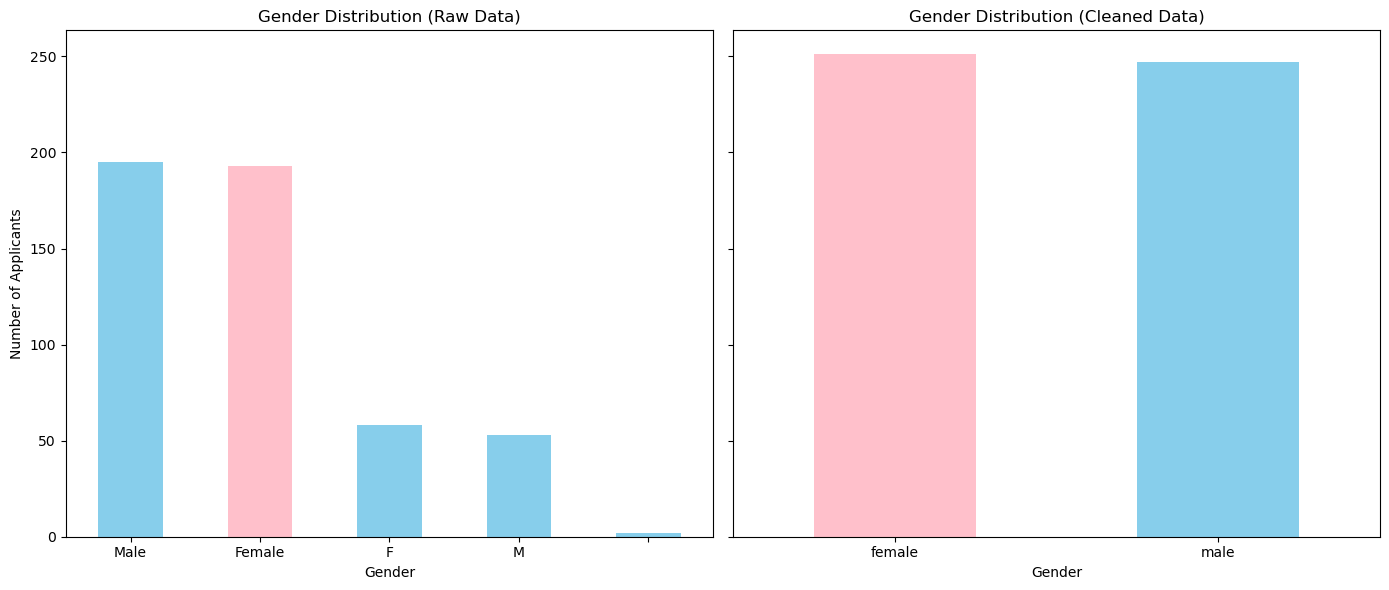

In [21]:
# Prepare the data for both dataframes
raw_counts = df_raw['applicant_info.gender'].value_counts()
clean_counts = df_clean['applicant_info.gender'].value_counts()

# Setup the figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Raw Data (Left side)
raw_colors = ['pink' if gender == 'Female' else 'skyblue' for gender in raw_counts.index]
raw_counts.plot(kind='bar', color=raw_colors, ax=ax1)
ax1.set_title('Gender Distribution (Raw Data)')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Number of Applicants')
ax1.tick_params(axis='x', rotation=0)

# Plot Cleaned Data (Right side)
clean_colors = ['pink' if gender == 'female' else 'skyblue' for gender in clean_counts.index]
clean_counts.plot(kind='bar', color=clean_colors, ax=ax2)
ax2.set_title('Gender Distribution (Cleaned Data)')
ax2.set_xlabel('Gender')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Consistency Problem Corrected

As we can see the consistency issue related to the Gender variable was successfully corrected in the 'Data Cleaning' Process.
On the df_cleaned the values "F" and "M" were correctly allocated to "female" and "male", respectively.

In [13]:
print("Columns in RAW data:")
print(df_raw.columns.tolist())

print("\nColumns in CLEANED data:")
print(df_clean.columns.tolist())

Columns in RAW data:
['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate', 'decision.approved_amount', 'financials.annual_salary', 'notes']

Columns in CLEANED data:
['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purp

In [19]:
# Define logical boundaries
MIN_INCOME = 0
MIN_MONTHS = 0

# PRE-AUDIT: Convert RAW data to numeric to allow comparison
raw_income_numeric = pd.to_numeric(df_raw['financials.annual_income'], errors='coerce')
raw_months_numeric = pd.to_numeric(df_raw['financials.credit_history_months'], errors='coerce')

# Audit Raw Data for Range Issues
raw_invalid_income = raw_income_numeric[raw_income_numeric < MIN_INCOME]
raw_invalid_months = raw_months_numeric[raw_months_numeric < MIN_MONTHS]

# Audit Cleaned Data (already numeric, so no conversion needed)
clean_invalid_income = df_clean[df_clean['financials.annual_income'] < MIN_INCOME]
clean_invalid_months = df_clean[df_clean['financials.credit_history_months'] < MIN_MONTHS]

# Create Comparison Summary
range_audit = pd.DataFrame({
    'Metric': ['Negative Annual Income', 'Negative Credit History Months'],
    'Raw': [len(raw_invalid_income), len(raw_invalid_months)],
    'Cleaned': [len(clean_invalid_income), len(clean_invalid_months)]
})

print("DATA QUALITY: RANGE CONSTRAINT VERIFICATION")
print(range_audit)

DATA QUALITY: RANGE CONSTRAINT VERIFICATION
                           Metric  Raw  Cleaned
0          Negative Annual Income    0        0
1  Negative Credit History Months    2        0


# Studies on Biases

### Approval Rate per Gender


Approval Rate per Gender:
applicant_info.gender
female    50.597610
male      65.991903
Name: decision.loan_approved, dtype: float64


<Axes: title={'center': 'Approval Rate (%) per Gender'}, xlabel='applicant_info.gender'>

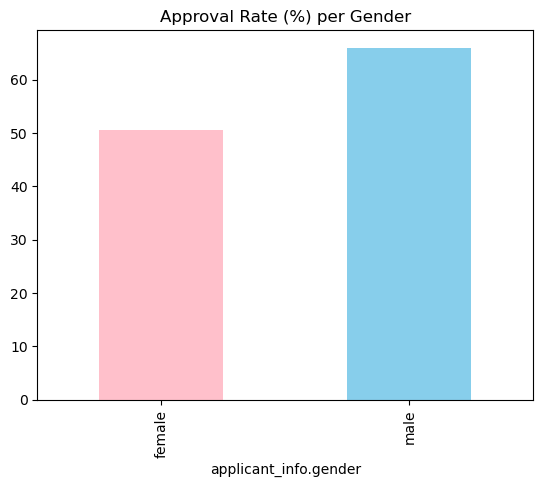

In [20]:
# Agrupar por género e calcular a média de 'loan_approved'
bias_analysis = df.groupby('applicant_info.gender')['decision.loan_approved'].mean() * 100

print("\nApproval Rate per Gender:")
print(bias_analysis)

# Criar um gráfico para o teu relatório de auditoria
bias_analysis.plot(kind='bar', color=['pink', 'skyblue'], title='Approval Rate (%) per Gender')

# The approval rate is considerably higher to "Male" customers comparing to "Female" one's

It is important to state that this difference alone does not necessarily mean that the approval system is unfair to women. But it is a good lead for us to conduct an investigation on the subject to understand what is causing this difference.

In [29]:
# Comparação de Médias Financeiras por Género
gender_profile = df_clean.groupby('applicant_info.gender')[['financials.annual_income', 'financials.debt_to_income', 'financials.credit_history_months','financials.savings_balance']].mean().round(2)

print("FINANCIAL PROFILE BY GENDER")
print(gender_profile)

print()

FINANCIAL PROFILE BY GENDER
                       financials.annual_income  financials.debt_to_income  \
applicant_info.gender                                                        
female                                 83770.65                       0.24   
male                                   81295.55                       0.25   

                       financials.credit_history_months  \
applicant_info.gender                                     
female                                            51.42   
male                                              49.78   

                       financials.savings_balance  
applicant_info.gender                              
female                                   29543.69  
male                                     29659.85  



In [45]:
# Filtrar apenas pelos empréstimos aprovados
approved_df = df_clean[df_clean['decision.loan_approved'] == True]

# Definir as 4 métricas
metrics = [
    'financials.annual_income', 
    'financials.debt_to_income', 
    'financials.credit_history_months', 
    'financials.savings_balance'
]

# Criar a tabela de comparação por Género
comparison_table = approved_df.groupby('applicant_info.gender')[metrics].agg(['mean', 'median']).round(2)

print("MINIMUM REQUIREMENTS FOR LOAN APPROVAL BY GENDER")
display(comparison_table)

# Cálculos
median_diff = comparison_table.xs('median', axis=1, level=1)

income_gap = (median_diff.loc['female', 'financials.annual_income'] / median_diff.loc['male', 'financials.annual_income'] - 1) * 100
savings_gap = (median_diff.loc['female', 'financials.savings_balance'] / median_diff.loc['male', 'financials.savings_balance'] - 1) * 100
history_gap = (median_diff.loc['female', 'financials.credit_history_months'] / median_diff.loc['male', 'financials.credit_history_months'] - 1) * 100
dti_gap = (median_diff.loc['female', 'financials.debt_to_income'] / median_diff.loc['male', 'financials.debt_to_income'] - 1) * 100

mean_diff = comparison_table.xs('mean', axis=1, level=1)

mean_income_gap = (mean_diff.loc['female', 'financials.annual_income'] / mean_diff.loc['male', 'financials.annual_income'] - 1) * 100
mean_savings_gap = (mean_diff.loc['female', 'financials.savings_balance'] / mean_diff.loc['male', 'financials.savings_balance'] - 1) * 100
mean_history_gap = (mean_diff.loc['female', 'financials.credit_history_months'] / mean_diff.loc['male', 'financials.credit_history_months'] - 1) * 100
mean_dti_gap = (mean_diff.loc['female', 'financials.debt_to_income'] / mean_diff.loc['male', 'financials.debt_to_income'] - 1) * 100

# Impressão dos resultados de Auditoria
print("\n\nGENDER GAP IN APPROVAL REQUIREMENTS\n")
print(f"1. Annual Income:\nApproved women have a median income {income_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean income {mean_income_gap:.1f}% higher/lower than approved men.")
print()
print(f"2. Savings Balance:\nApproved women have a median savings balance {savings_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean savings balance {mean_savings_gap:.1f}% higher/lower than approved men.")
print()
print(f"3. Credit History:\nApproved women have a median history length {history_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean history lenght {mean_history_gap:.1f}% higher/lower than approved men.")
print()
print(f"4. Debt-to-Income:\nApproved women have a median DTI ratio {dti_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean DIT {mean_dti_gap:.1f}% higher/lower than approved men.")

MINIMUM REQUIREMENTS FOR LOAN APPROVAL BY GENDER


financials.annual_income           \
                                          mean   median   
applicant_info.gender                                     
female                                90570.34  89000.0   
male                                  83742.33  82000.0   

                      financials.debt_to_income         \
                                           mean median   
applicant_info.gender                                    
female                                     0.25   0.23   
male                                       0.24   0.24   

                      financials.credit_history_months         \
                                                  mean median   
applicant_info.gender                                           
female                                           55.58   54.0   
male                                             53.25   49.0   

                      financials.savings_balance           
                                            mean   median  
applicant_info.gender                                      
female                                  33322.79  29386.0  
male                                    30000.40  28670.0



GENDER GAP IN APPROVAL REQUIREMENTS

1. Annual Income:
Approved women have a median income 8.5% higher/lower than approved men.
Approved women have a mean income 8.2% higher/lower than approved men.

2. Savings Balance:
Approved women have a median savings balance 2.5% higher/lower than approved men.
Approved women have a mean savings balance 11.1% higher/lower than approved men.

3. Credit History:
Approved women have a median history length 10.2% higher/lower than approved men.
Approved women have a mean history lenght 4.4% higher/lower than approved men.

4. Debt-to-Income:
Approved women have a median DTI ratio -4.2% higher/lower than approved men.
Approved women have a mean DIT 4.2% higher/lower than approved men.


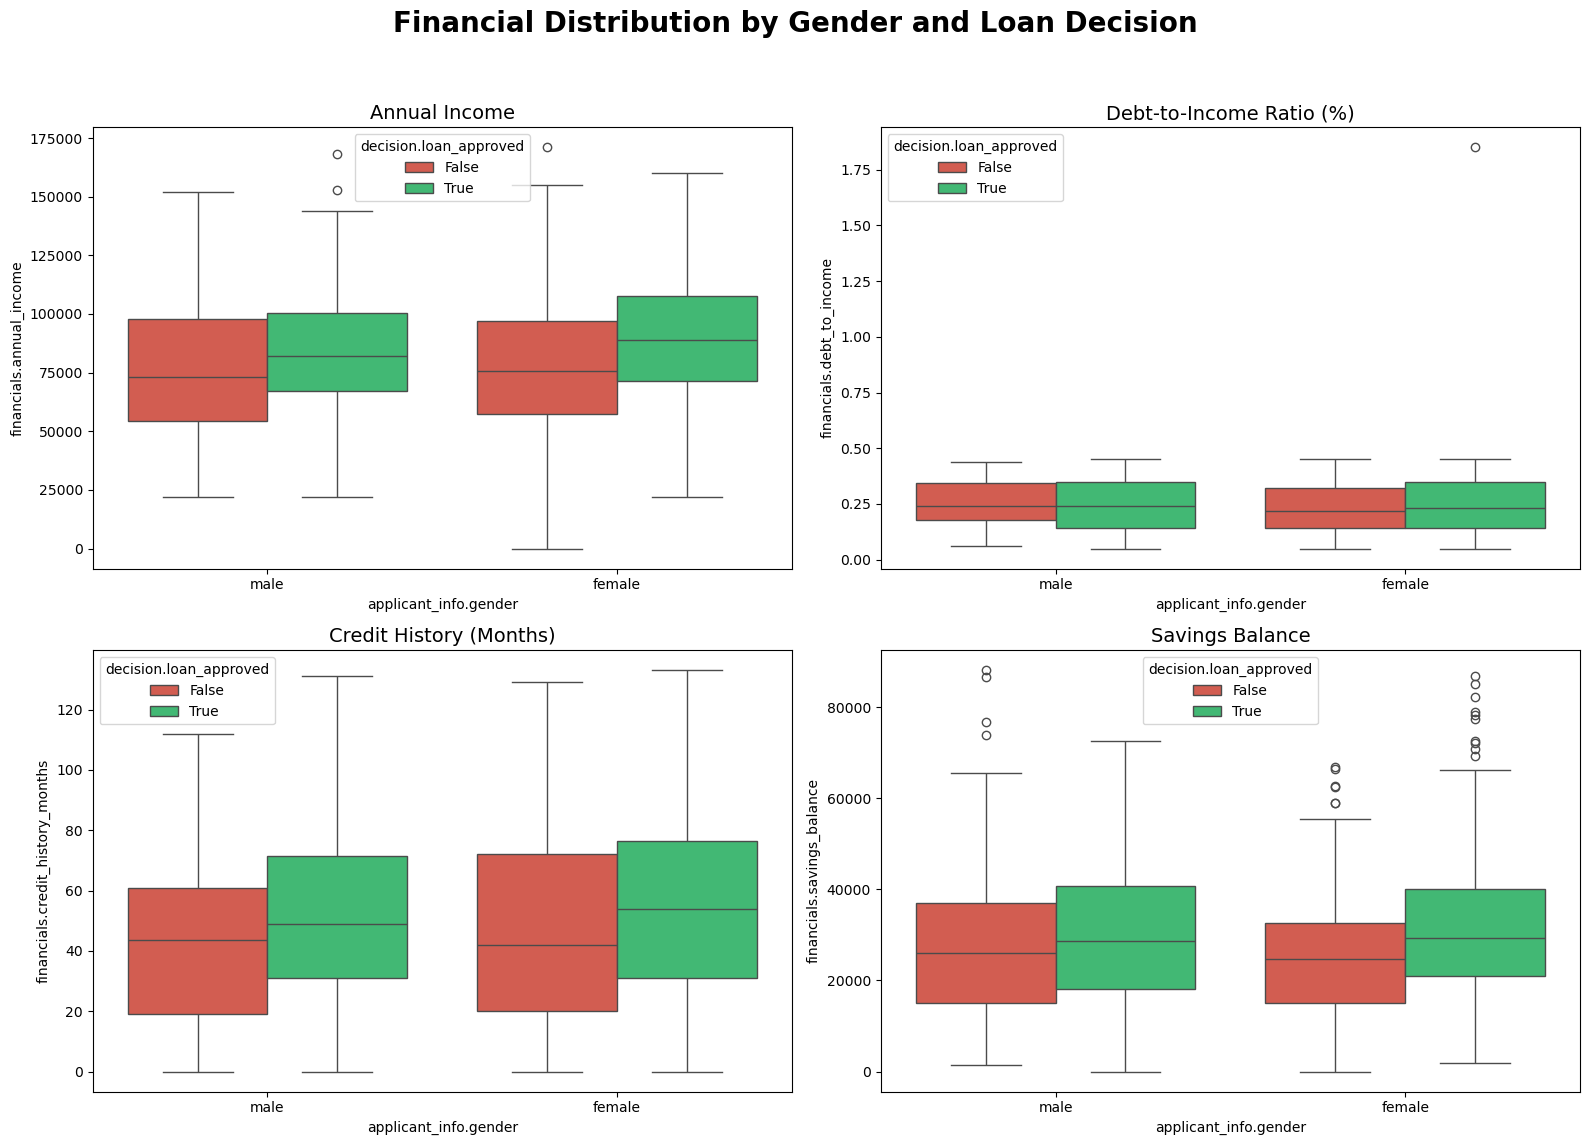

In [32]:
# Definir a paleta de cores intuitiva
custom_palette = {True: "#2ecc71", False: "#e74c3c"}

# Configurar a figura para 4 subplots (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Financial Distribution by Gender and Loan Decision', fontsize=20, fontweight='bold')

# Subplot 1: Annual Income
sns.boxplot(ax=axes[0, 0], x='applicant_info.gender', y='financials.annual_income', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[0, 0].set_title('Annual Income', fontsize=14)

# Subplot 2: Debt-to-Income (DTI)
sns.boxplot(ax=axes[0, 1], x='applicant_info.gender', y='financials.debt_to_income', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[0, 1].set_title('Debt-to-Income Ratio (%)', fontsize=14)

# Subplot 3: Credit History
sns.boxplot(ax=axes[1, 0], x='applicant_info.gender', y='financials.credit_history_months', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[1, 0].set_title('Credit History (Months)', fontsize=14)

# Subplot 4: Savings Balance
sns.boxplot(ax=axes[1, 1], x='applicant_info.gender', y='financials.savings_balance', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[1, 1].set_title('Savings Balance', fontsize=14)

# Ajustar o layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()